In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
%pip install numpy
%pip install statistics
%pip install scipy
%pip install matplotlib
%pip install pandas
%pip install pytest

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrad

In [3]:
import numpy
import pandas
from src.validate import Validate
from src.district_population import DistrictPopulation

years = list(range(2015, 2025))
Kampala = [1200, 1250, 1300, 1350, 1420, 1500, 1580, 1650, 1720, 1800]
Wakiso  = [ 950, 1000, 1070, 1150, 1220, 1300, 1390, 1480, 1570, 1670]
Gulu    = [ 320,  330,  345,  360,  375,  390,  410,  430,  455,  480]
Kabale    = [ 570,  590,  630,  640,  712,  733,  750,  765,  775,  790]
Masindi    = [270,  300,  310,  340,  360,  383,  390,  400,  410,  440]
populations = [Kampala, Wakiso, Gulu, Kabale, Masindi]
districts = ["Kampala", "Wakiso", 'Gulu', 'Kabale', 'Masindi']
models = ['Linear', 'Cagr','Fibonacci']

#create validate object
validate  = Validate()

all_populations = {'Kampala': Kampala, 'Wakiso': Wakiso, 'Gulu': Gulu, 'Kabale':Kabale, 'Masindi':Masindi}
#Print out numpy, statistics numbers by district
results = []

try:
    for district_name, populations in all_populations.items():
        district_stat_obj = DistrictPopulation(validate, numpy.array(years),numpy.array(populations),district_name)
        
        results.append({
            'District': district_name,
            'Module': '(Numpy)',
            'Mean': district_stat_obj.mean(),
            'Median': district_stat_obj.median(),
            'Variance': district_stat_obj.variance(),
            'Std Dev': district_stat_obj.standard_deviation()
            })

        results.append({
            'District': district_name,
            'Module': '(Statistics)',
            'Mean': district_stat_obj.mean('statistics'),
            'Median': district_stat_obj.median('statistics'),
            'Variance': district_stat_obj.variance('statistics'),
            'Std Dev': district_stat_obj.standard_deviation('statistics')
            })

    df = pandas.DataFrame(results).round(2)

    print(df.to_string(index=False))
except Exception as e:
    print("Error: ", e) 


District       Module   Mean  Median  Variance  Std Dev
 Kampala      (Numpy) 1477.0  1460.0  38341.00   195.81
 Kampala (Statistics) 1477.0  1460.0  42601.11   206.40
  Wakiso      (Numpy) 1280.0  1260.0  54060.00   232.51
  Wakiso (Statistics) 1280.0  1260.0  60066.67   245.09
    Gulu      (Numpy)  389.5   382.5   2597.25    50.96
    Gulu (Statistics)  389.5   382.5   2885.83    53.72
  Kabale      (Numpy)  695.5   722.5   5898.05    76.80
  Kabale (Statistics)  695.5   722.5   6553.39    80.95
 Masindi      (Numpy)  360.3   371.5   2652.81    51.51
 Masindi (Statistics)  360.3   371.5   2947.57    54.29


The statistics.variance and  np.var give different numbers because statistics.variance() calculates sample variance, while numpy.var() calculates population variance by default
- Numpy.var treats the data input as the complete set of values, so it divides the total squared differences from the mean by the number of observations, N. 
- Python's statistics.variance() treats the data as a sample taken from a larger population, so it divides by N − 1. Because N − 1 is smaller than N, the resulting variance is larger

The ddof argument in NumPy controls this difference: ddof=0 means divide by N, while ddof=1 means divide by N − 1. Therefore, statistics.variance() and NumPy's variance with ddof=1 produce the same result

The same applies to standard deviation, which is the square root of the variance. numpy.std() divides by N and statistics.stdev() divides by N − 1, so the Std Dev in each row is the square root of the Variance in that row.

### Growth Rate and CAGR section

In [4]:
cagr_by_district = {}

all_populations = {'Kampala': Kampala, 'Wakiso': Wakiso, 'Gulu': Gulu, 'Kabale':Kabale, 'Masindi':Masindi}
try:
        #print out growth rates and CAGR by district
        for district_name, populations in all_populations.items():
                district_growth_obj = DistrictPopulation(validate, numpy.array(years), numpy.array(populations), district_name)
                print(repr(district_growth_obj), ':Annual Growth Rate')
                growth = district_growth_obj.year_on_year_growth()
                growth_table = pandas.DataFrame([growth])
                print(growth_table.to_string(index=False))
                cagr_by_district[district_name] = district_growth_obj.compound_annual_growth_rate()
                print('compound annual growth rate(CAGR):' + str(cagr_by_district[district_name]), '\n')
        
    
        #Get the fastest growing district
        fastest_growing_district = max(cagr_by_district, key=cagr_by_district.get)
        print("\n" , f"NOTE: The fastest growing distict is: {fastest_growing_district}") 
except Exception as e:
    print("Error: ", e) 

Kampala district :Annual Growth Rate
2015   2016 2017   2018   2019   2020   2021  2022   2023   2024
 N/A 4.167% 4.0% 3.846% 5.185% 5.634% 5.333% 4.43% 4.242% 4.651%
compound annual growth rate(CAGR):0.04608191864321465 

Wakiso district :Annual Growth Rate
2015   2016 2017   2018   2019   2020   2021   2022   2023   2024
 N/A 5.263% 7.0% 7.477% 6.087% 6.557% 6.923% 6.475% 6.081% 6.369%
compound annual growth rate(CAGR):0.06468572090369085 

Gulu district :Annual Growth Rate
2015   2016   2017   2018   2019 2020   2021   2022   2023   2024
 N/A 3.125% 4.545% 4.348% 4.167% 4.0% 5.128% 4.878% 5.814% 5.495%
compound annual growth rate(CAGR):0.04608191864321465 

Kabale district :Annual Growth Rate
2015   2016  2017   2018   2019   2020   2021 2022   2023   2024
 N/A 3.509% 6.78% 1.587% 11.25% 2.949% 2.319% 2.0% 1.307% 1.935%
compound annual growth rate(CAGR):0.03693193141165918 

Masindi district :Annual Growth Rate
2015    2016   2017   2018   2019   2020   2021   2022 2023   2024
 N/A 

### Prediction Models section

In [5]:
#prediction year
prediction_years = years[7:]

training_populations = {'Kampala': Kampala[:7], 'Wakiso': Wakiso[:7], 'Gulu': Gulu[:7], 'Kabale':Kabale[:7], 'Masindi':Masindi[:7]}

#target data
actual_populations = {'Kampala': Kampala[7:], 'Wakiso': Wakiso[7:], 'Gulu': Gulu[7:], 'Kabale':Kabale[7:], 'Masindi':Masindi[7:]}
try:
    predictions = {}
    for district_name, populations in all_populations.items():
        training_data = training_populations[district_name]
        actual_data = actual_populations[district_name]
        district_model_obj = DistrictPopulation(validate, numpy.array(years[:7]), numpy.array(training_data), district_name)
        #new inner dictionary for the district
        predictions[district_name] = {}
        #include actual data
        predictions[district_name]['Actual-data'] = {}
        predictions[district_name]['Actual-data']['forecast'] = actual_data
        predictions[district_name]['Actual-data']['metrics'] = {'MAE':'N/A', 'RMSE': 'N/A', 'MAPE': 'N/A'}
        
        #handle the predictions and mae, rsme, mape
        for model in models:
            predictions[district_name][model] =  {}
            forecast = district_model_obj.prediction(len(actual_data), model)
            predictions[district_name][model]['forecast'] = forecast
            predictions[district_name][model]['metrics'] =  district_model_obj.prediction_metrics(numpy.array(actual_data),forecast)
        
        predictions[district_name]['best-model'] = district_model_obj.best_model(predictions[district_name])      

    print("Model Training Results")

    for district, inner_models in predictions.items():

        results = []
        for i_model, m_data in inner_models.items():
            #skip this, its does not have details
            if i_model == 'best-model':
                continue

            row = {'Model': i_model,**dict(zip(prediction_years, m_data['forecast']))}

            if 'metrics' in m_data:
                metrics = m_data['metrics']
                row.update({'MAE': metrics['MAE'], 'RMSE': metrics['RMSE'],'MAPE': metrics['MAPE']})

            results.append(row)

        df = pandas.DataFrame(results).round(2)

        print(f"\n{district}")
        print(df.to_string(index=False))
        print(f"Best Model: {inner_models['best-model']}")
except Exception as e:
    print("Error: ", e) 

Model Training Results

Kampala
      Model    2022    2023    2024     MAE     RMSE   MAPE
Actual-data 1650.00 1720.00 1800.00     N/A      N/A    N/A
     Linear 1622.86 1685.71 1748.57   37.62    38.97   2.17
       Cagr 1654.13 1731.74 1812.99    9.62    10.39   0.55
  Fibonacci 3160.00 2370.00 2633.33  997.78  1064.12  58.53
Best Model: Cagr

Wakiso
      Model    2022    2023    2024     MAE    RMSE   MAPE
Actual-data 1480.00 1570.00 1670.00     N/A     N/A    N/A
     Linear 1450.00 1523.93 1597.86    49.4   52.37   3.09
       Cagr 1481.03 1578.02 1681.36     6.8    8.05   0.42
  Fibonacci 2780.00 2085.00 2316.67  820.56  889.46  53.12
Best Model: Cagr

Gulu
      Model   2022   2023   2024     MAE    RMSE   MAPE
Actual-data 430.00 455.00 480.00     N/A     N/A    N/A
     Linear 421.43 436.43 451.43   18.57   20.29   4.01
       Cagr 427.29 445.31 464.09    9.44   10.87   2.02
  Fibonacci 820.00 615.00 683.33  251.11  270.21  56.07
Best Model: Cagr

Kabale
      Model    2022 

### Best model forecast


In [6]:
#use best models to do prediction
bm_prediction_years = [2025, 2026, 2027, 2028, 2029]
bm_prediction = {}
for d in districts:
    best_model = predictions[d]['best-model']
    districtObj = DistrictPopulation(validate, numpy.array(years), numpy.array(all_populations[d]), d)
    bm_prediction[d] = districtObj.prediction(len(bm_prediction_years), best_model)

#one row per district, one column per year
df = pandas.DataFrame.from_dict(bm_prediction, orient='index', columns=bm_prediction_years).round(2)
df.insert(0, 'Best Model', [predictions[d]['best-model'] for d in df.index])
df.index.name = 'District'

print(df.to_string())

         Best Model     2025     2026     2027     2028     2029
District                                                        
Kampala        Cagr  1882.95  1969.72  2060.49  2155.44  2254.76
Wakiso         Cagr  1778.03  1893.04  2015.49  2145.86  2284.67
Gulu           Cagr   502.12   525.26   549.46   574.78   601.27
Kabale         Cagr   819.18   849.43   880.80   913.33   947.06
Masindi      Linear   457.73   475.45   493.16   510.88   528.59


### compare the variance of the actual series against the variance of the forecast series

In [7]:
rows = []
for district_name, populations in all_populations.items():
    actual = numpy.array(populations)
    forecast = bm_prediction[district_name]

    #level variance: full actual series (10 years), last 5 actual years, and the 5 forecast years
    actual_var = DistrictPopulation(validate, numpy.array(years), actual, district_name).variance()
    recent_var = DistrictPopulation(validate, numpy.array(years[-5:]), actual[-5:], district_name).variance()
    forecast_var = DistrictPopulation(validate, numpy.array(bm_prediction_years), forecast, district_name).variance()

    #year-to-year changes remove the trend: 2016-2024 for actual, 2025-2029 for forecast (starting from 2024)
    actual_changes = numpy.diff(actual)
    forecast_changes = numpy.diff(numpy.append(actual[-1], forecast))
    actual_change_var = DistrictPopulation(validate, numpy.array(years[1:]), actual_changes, district_name).variance()
    forecast_change_var = DistrictPopulation(validate, numpy.array(bm_prediction_years), forecast_changes, district_name).variance()

    rows.append({
        'District': district_name,
        'Best Model': predictions[district_name]['best-model'],
        'Var actual 2015-24': actual_var,
        'Var actual 2020-24': recent_var,
        'Var forecast 2025-29': forecast_var,
        'Ratio (5y vs 5y)': forecast_var / recent_var,
        'Var yearly change actual': actual_change_var,
        'Var yearly change forecast': forecast_change_var,
    })

print(pandas.DataFrame(rows).round(2).to_string(index=False))

District Best Model  Var actual 2015-24  Var actual 2020-24  Var forecast 2025-29  Ratio (5y vs 5y)  Var yearly change actual  Var yearly change forecast
 Kampala       Cagr            38341.00            10960.00              17286.15              1.58                    155.56                       33.55
  Wakiso       Cagr            54060.00            16936.00              32105.09              1.90                    200.00                      118.51
    Gulu       Cagr             2597.25             1016.00               1229.24              1.21                     22.84                        2.39
  Kabale       Cagr             5898.05              389.04               2044.74              5.26                    354.02                        2.59
 Masindi     Linear             2652.81              396.64                627.65              1.58                     85.21                        0.00


#### Variance of the actual values compared with the forecasts

The ratio divides the variance of the 2025–29 forecast by the variance of the actual values for 2020–24. A ratio above 1 means the forecast covers a wider range than the last five actual years. Since population keeps growing, this mostly shows how steeply each series rises, not how much it fluctuates.

Every ratio is above 1, so all forecasts rise faster than the recent actual data. Gulu stays closest to its recent trend (1.21), followed by Kampala and Masindi (1.58) and Wakiso (1.90). Kabale stands out at 5.26. Its growth slowed from about 5.7% a year over 2015–19 to 1.9% a year over 2020–24, but its CAGR forecast is fitted on the full 2015–24 series and grows at the ten-year rate of 3.7% a year, about twice the recent rate. A single fixed growth rate cannot follow a slowdown like this, so a model fitted on recent years, or one that lets the rate change, would suit Kabale better.

The yearly change columns measure fluctuation more directly. All forecasts are far smoother than the actual data. Masindi's Linear forecast scores 0.00 because it adds the same amount each year, while CAGR forecasts vary slightly because a fixed growth rate produces slowly increasing yearly gains.

All the forecasts are single values with no range around them, and they rest on only ten years of data. Over the three test years, the best models' errors (MAPE) ran from 0.42% in Wakiso to 5.86% in Kabale. Errors usually grow the further ahead a forecast runs, so the 2029 values are less certain than those test results suggest.

### Actual, fitted and forecast values by district

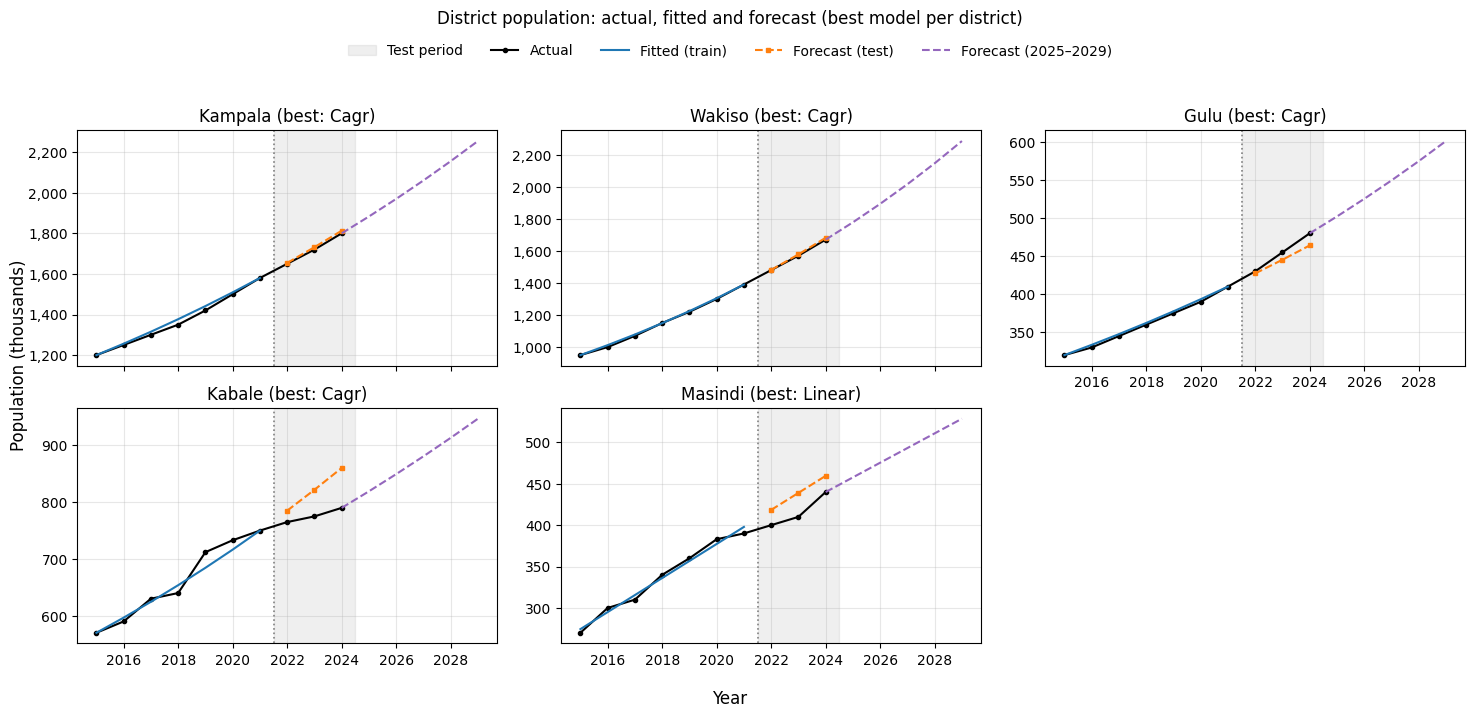

In [8]:
import matplotlib.pyplot as plt
from src.plots import plot_district_forecasts

fig = plot_district_forecasts(validate, years, all_populations, train_size=7,
                              predictions=predictions,
                              future_years=bm_prediction_years,
                              future_forecasts=bm_prediction,
                              y_label='Population (thousands)')
fig.savefig('district_forecasts.png', dpi=150, bbox_inches='tight')
plt.show()

### Planning output: additional primary-school classrooms by 2029

Assume 18% of the population is of primary-school age and a classroom holds 53 pupils.

In [9]:
from src.planning import ClassroomPlanner

try:
    # The population data is in thousands, so multiply by 1000 to get headcount
    planner = ClassroomPlanner(school_age_share=0.18, class_size=53, population_unit=1000)

    rows = []
    for district_name, populations in all_populations.items():
        pop_2024 = populations[-1]
        pop_2029 = bm_prediction[district_name][-1]
        rows.append({
            'District': district_name,
            'Best Model': predictions[district_name]['best-model'],
            'Population 2024 (thousands)': pop_2024,
            'Population 2029 (thousands)': pop_2029,
            'Pupils 2029': planner.pupils(pop_2029),
            'Classrooms 2024': planner.classrooms_needed(pop_2024),
            'Classrooms 2029': planner.classrooms_needed(pop_2029),
            'Additional by 2029': planner.additional_classrooms(pop_2024, pop_2029),
        })

    classrooms_df = pandas.DataFrame(rows).round(2)
    print(classrooms_df.to_string(index=False))
except Exception as e:
    print("Error: ", e)

District Best Model  Population 2024 (thousands)  Population 2029 (thousands)  Pupils 2029  Classrooms 2024  Classrooms 2029  Additional by 2029
 Kampala       Cagr                         1800                      2254.76    405857.42             6114             7658                1544
  Wakiso       Cagr                         1670                      2284.67    411240.73             5672             7760                2088
    Gulu       Cagr                          480                       601.27    108228.64             1631             2043                 412
  Kabale       Cagr                          790                       947.06    170471.13             2684             3217                 533
 Masindi     Linear                          440                       528.59     95146.91             1495             1796                 301


#### Assumptions and limitations

- **Existing classrooms:** there is no data on current classrooms, so each district is assumed to have exactly enough classrooms for its 2024 primary-school population. The additional figure is the 2029 need minus the 2024 need.
- **Rounding:** the existing classrooms are assumed to be the 2024 need rounded up, which is a whole number (6,114 in Kampala). The additional figure is therefore the 2029 need rounded up, minus that whole number. Rounding up only the difference between the two pupil counts would count part of a classroom already covered by the 2024 rounding, giving one more classroom in Kampala (1,545) and Kabale (534).
- **Fixed ratios:** the 18% school-age share and the 53-pupil class size are held constant from 2024 to 2029.
- **Forecast dependence:** the estimates are only as reliable as each district's 2029 forecast. Kabale's 533 depends on its CAGR forecast, which the variance table above shows running ahead of recent growth (a ratio of 5.26, against 1.21 to 1.90 for the other districts). Kabale's growth has slowed since 2019, so its figure is likely an overestimate.

### Findings & Limitations

**Findings.** Wakiso is the fastest-growing district, with a 2015–24 CAGR of 6.5%, followed by Masindi (5.6%), Kampala and Gulu (4.6% each) and Kabale (3.7%). On the 2022–24 test years, CAGR was the most accurate model for four districts, with a MAPE as low as 0.42% in Wakiso and 0.55% in Kampala. Linear was best for Masindi, with a MAPE of 5.38%. The Fibonacci ratio model was the least accurate in every district (MAPE 53% to 66%), because its first forecast doubles the last training value. Using each district's best model, Wakiso overtakes Kampala in 2029, at 2,285 thousand against 2,255 thousand. With 18% of the population of primary-school age and 53 pupils per classroom, the five districts need 4,878 more classrooms by 2029, led by Wakiso (2,088) and Kampala (1,544).

**Limitations.** Each forecast rests on ten data points and a three-year test period, so a longer series could change which model is best, and the forecasts give single values with no range around them. CAGR and Linear both assume the trend stays constant. Kabale's growth slowed from about 5.7% a year over 2015–19 to 1.9% over 2020–24, so its forecast, and its 533 classrooms, are likely too high. The classroom estimate also assumes that current classrooms exactly meet 2024 need, that the school-age share and class size stay fixed, and that the population data is in thousands.